# 01 · Exploración del dataset NEU

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EstebanGuerrero125/steel-defect-detection-cnn/blob/main/notebooks/01_exploracion_dataset.ipynb)

**Objetivo:** descargar el dataset NEU Surface Defect Database, entender su estructura y verificar la calidad de los datos antes de entrenar cualquier modelo.

Preguntas que responde este notebook:

1. ¿Cuántas imágenes hay por clase y por partición? ¿Está balanceado?
2. ¿Todas las imágenes tienen el mismo tamaño y formato?
3. ¿Hay imágenes corruptas o duplicadas? ¿Hay fuga de datos entre *train* y *validation*?
4. ¿Cómo se ve cada tipo de defecto y qué tan distinguibles son entre sí?

## 1. Configuración

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/EstebanGuerrero125/steel-defect-detection-cnn.git"

if IN_COLAB:
    # En Colab se clona el repositorio para reutilizar el código de src/
    if not Path("steel-defect-detection-cnn").exists():
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    ROOT = Path("steel-defect-detection-cnn").resolve()
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /content/steel-defect-detection-cnn


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from src.dataset import CLASSES, add_metadata, build_index

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 2. Descarga del dataset

Se usa [`kagglehub`](https://github.com/Kaggle/kagglehub), que descarga el dataset y lo guarda en caché (si ya existe, no lo vuelve a descargar).

> Si Kaggle pide autenticación, ejecuta `kagglehub.login()` y pega tu usuario y token de Kaggle (kaggle.com → Settings → API → *Create New Token*). **Nunca subas tu token al repositorio.**

In [3]:
try:
    import kagglehub
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub

DATA_PATH = Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
print("Dataset en:", DATA_PATH)

100%|██████████| 26.4M/26.4M [00:00<00:00, 105MB/s] 

Extracting files...


Dataset en: /root/.cache/kagglehub/datasets/kaustubhdikshit/neu-surface-defect-database/versions/1


Estructura de carpetas del dataset:

In [4]:
for folder in sorted(p for p in DATA_PATH.rglob("*") if p.is_dir()):
    n_files = sum(1 for f in folder.iterdir() if f.is_file())
    depth = len(folder.relative_to(DATA_PATH).parts) - 1
    print(f"{'    ' * depth}{folder.name}/  ({n_files} archivos)")

NEU-DET/  (0 archivos)
    train/  (0 archivos)
        annotations/  (1439 archivos)
        images/  (0 archivos)
            crazing/  (240 archivos)
            inclusion/  (240 archivos)
            patches/  (240 archivos)
            pitted_surface/  (240 archivos)
            rolled-in_scale/  (240 archivos)
            scratches/  (240 archivos)
    validation/  (0 archivos)
        annotations/  (361 archivos)
        images/  (0 archivos)
            crazing/  (60 archivos)
            inclusion/  (60 archivos)
            patches/  (60 archivos)
            pitted_surface/  (60 archivos)
            rolled-in_scale/  (60 archivos)
            scratches/  (60 archivos)


## 3. Índice de imágenes

`build_index` (en `src/dataset.py`) recorre el dataset y crea una tabla con una fila por imagen: ruta, clase y partición. La clase se toma del nombre de la carpeta y la partición de la ruta (`train` / `validation`). Esta tabla es la base de todo el análisis y del entrenamiento.

In [5]:
df = build_index(DATA_PATH)
print(f"Total de imágenes: {len(df)}")
df.head()

Total de imágenes: 1800


,path,filename,label,split
0,/root/.cache/kagglehub/datasets/kaustubhdikshi...,crazing_1.jpg,crazing,train
1,/root/.cache/kagglehub/datasets/kaustubhdikshi...,crazing_10.jpg,crazing,train
2,/root/.cache/kagglehub/datasets/kaustubhdikshi...,crazing_100.jpg,crazing,train
3,/root/.cache/kagglehub/datasets/kaustubhdikshi...,crazing_101.jpg,crazing,train
4,/root/.cache/kagglehub/datasets/kaustubhdikshi...,crazing_102.jpg,crazing,train


## 4. Distribución de clases

In [6]:
pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")

split,train,validation,total
label,,,
crazing,240,60,300
inclusion,240,60,300
patches,240,60,300
pitted_surface,240,60,300
rolled_in_scale,240,60,300
scratches,240,60,300
total,1440,360,1800


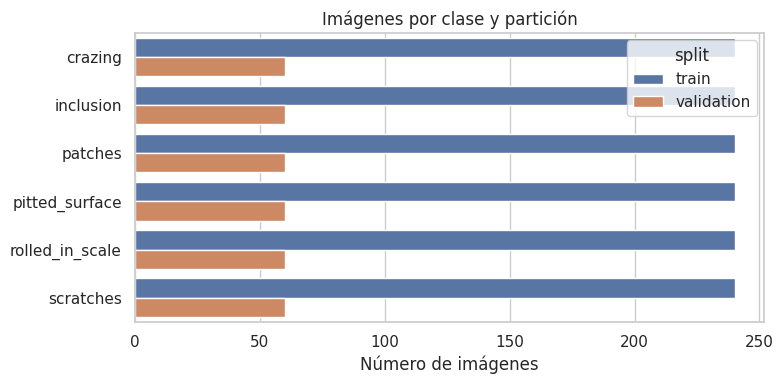

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, y="label", hue="split", order=CLASSES, ax=ax)
ax.set(title="Imágenes por clase y partición", xlabel="Número de imágenes", ylabel="")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribucion_clases.png", dpi=150)
plt.show()

## 5. Calidad de los datos

Antes de entrenar se verifica:

- **Formato:** tamaño y modo de color de cada imagen.
- **Integridad:** que ninguna imagen esté corrupta.
- **Duplicados:** imágenes con el mismo contenido (mismo hash MD5).
- **Fuga de datos:** la misma imagen en *train* y en *validation* inflaría artificialmente las métricas.

In [8]:
df = add_metadata(df)

print("Imágenes corruptas:", int(df["corrupt"].sum()))
df.groupby(["width", "height", "mode"], dropna=False).size().rename("imagenes").reset_index()

Imágenes corruptas: 0


,width,height,mode,imagenes
0,200,200,RGB,1800


In [9]:
dup_mask = df.duplicated("md5", keep=False)
print("Imágenes con contenido duplicado:", int(dup_mask.sum()))

by_hash = df.groupby("md5").agg(n_splits=("split", "nunique"), n_labels=("label", "nunique"))
print("Duplicados presentes en más de una partición (fuga):", int((by_hash["n_splits"] > 1).sum()))
print("Duplicados con etiquetas distintas (conflicto):", int((by_hash["n_labels"] > 1).sum()))

df.loc[dup_mask, ["filename", "label", "split", "md5"]].sort_values("md5").head(20)

Imágenes con contenido duplicado: 2
Duplicados presentes en más de una partición (fuga): 0
Duplicados con etiquetas distintas (conflicto): 0


,filename,label,split,md5
483,patches_101.jpg,patches,train,24f39e0f91f95e4c785052ac4d3e49a6
487,patches_105.jpg,patches,train,24f39e0f91f95e4c785052ac4d3e49a6


In [10]:
# Las imágenes corruptas no se pueden usar: se excluyen del resto del análisis
df = df[~df["corrupt"]].reset_index(drop=True)
print("Imágenes válidas:", len(df))

Imágenes válidas: 1800


## 6. Ejemplos de cada defecto

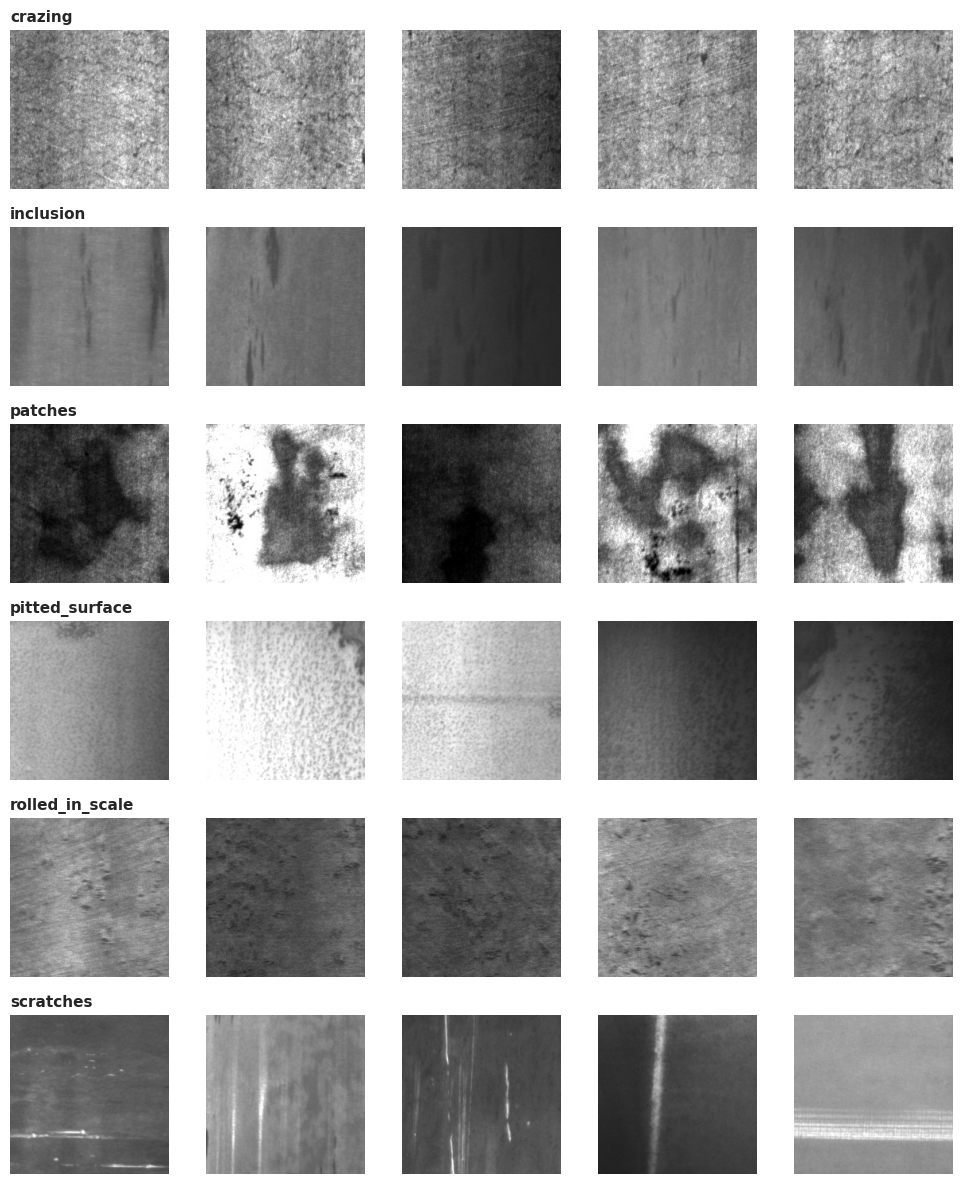

In [11]:
N_EXAMPLES = 5
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES, figsize=(2 * N_EXAMPLES, 2 * len(CLASSES)))
for i, cls in enumerate(CLASSES):
    paths = df.loc[df["label"] == cls, "path"].to_numpy()
    for j, path in enumerate(rng.choice(paths, N_EXAMPLES, replace=False)):
        axes[i, j].imshow(Image.open(path).convert("L"), cmap="gray", vmin=0, vmax=255)
        axes[i, j].axis("off")
    axes[i, 0].set_title(cls, loc="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_ejemplos_por_clase.png", dpi=150)
plt.show()

## 7. Intensidad de píxeles por clase

El brillo medio y el contraste (desviación estándar) de cada imagen ayudan a ver si algunas clases se distinguen solo por iluminación. Si fuera así, el modelo podría aprender un atajo en lugar de la forma del defecto.

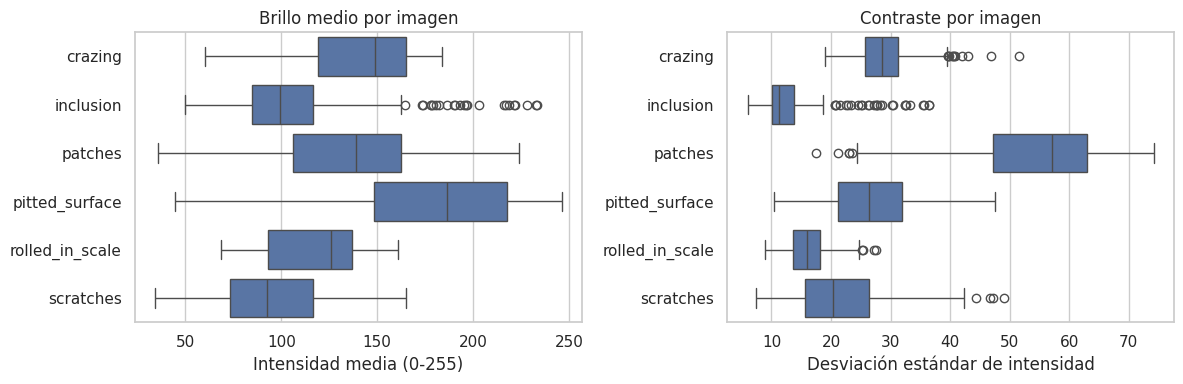

brillo_medio             contraste      
                        mean        std       mean   std
label                                                   
crazing           141.100006  28.700001  29.100000   4.8
inclusion         106.400002  33.900002  13.000000   5.5
patches           132.500000  43.099998  54.200001  12.3
pitted_surface    176.699997  49.299999  26.700001   7.7
rolled_in_scale   117.900002  24.600000  16.100000   3.5
scratches          95.099998  29.100000  21.700001   8.3

In [12]:
def intensity_stats(path):
    arr = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    return arr.mean(), arr.std()

df[["brillo_medio", "contraste"]] = pd.DataFrame(
    [intensity_stats(p) for p in df["path"]], index=df.index
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="brillo_medio", y="label", order=CLASSES, ax=axes[0])
sns.boxplot(data=df, x="contraste", y="label", order=CLASSES, ax=axes[1])
axes[0].set(title="Brillo medio por imagen", xlabel="Intensidad media (0-255)", ylabel="")
axes[1].set(title="Contraste por imagen", xlabel="Desviación estándar de intensidad", ylabel="")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_intensidad_por_clase.png", dpi=150)
plt.show()

df.groupby("label")[["brillo_medio", "contraste"]].agg(["mean", "std"]).round(1)

### Imagen promedio por clase

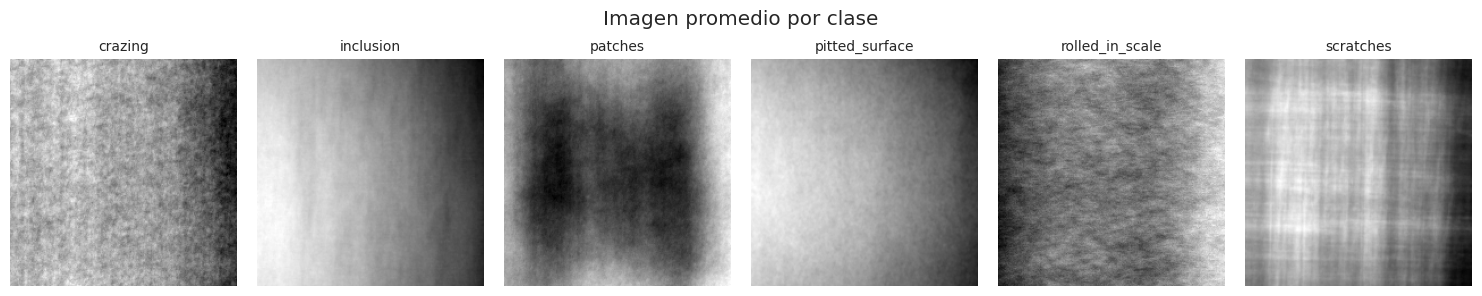

In [13]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(2.5 * len(CLASSES), 3))
for ax, cls in zip(axes, CLASSES):
    stack = [np.asarray(Image.open(p).convert("L").resize((200, 200)), dtype=np.float32)
             for p in df.loc[df["label"] == cls, "path"]]
    ax.imshow(np.mean(stack, axis=0), cmap="gray")
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.suptitle("Imagen promedio por clase")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_imagen_promedio.png", dpi=150)
plt.show()


**Siguiente paso:** entrenar una CNN pequeña desde cero como *baseline* (`02_cnn_baseline.ipynb`).